In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [36]:
iris = load_iris()


In [37]:
X_reg = iris.data[:, 2].reshape(-1, 1)

In [ ]:
np.random.seed(42)
noise = np.random.normal(0, 0.5, (X_reg.shape[0], 1))
y_reg = 2 + 0.5 * X_reg + 2 * (X_reg ** 2) + noise


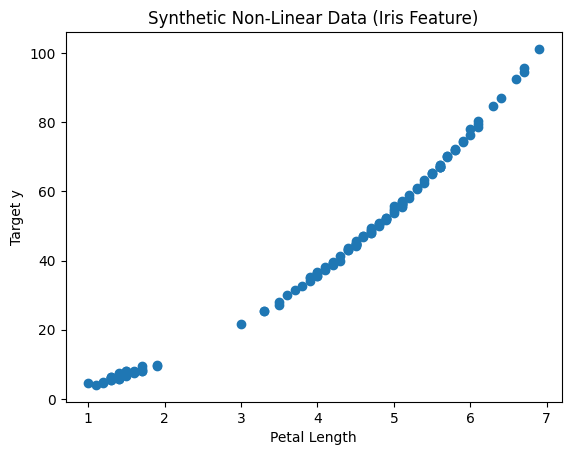

In [ ]:
plt.figure()
plt.scatter(X_reg, y_reg)
plt.title("Synthetic Non-Linear Data (Iris Feature)")
plt.xlabel("Petal Length")
plt.ylabel("Target y")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
X_plot = np.linspace(X_reg.min(), X_reg.max(), 200).reshape(-1, 1)
y_plot_linear = linear_model.predict(X_plot)

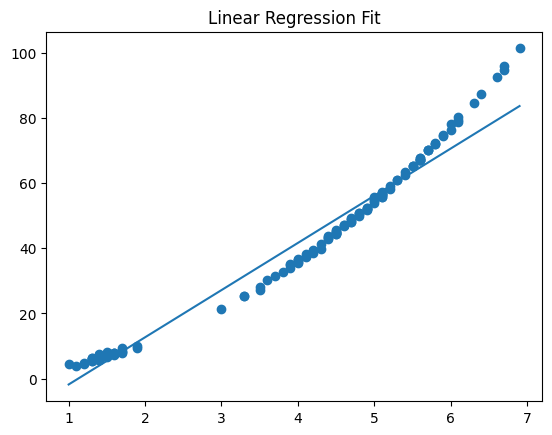

In [ ]:
plt.figure()
plt.scatter(X_reg, y_reg)
plt.plot(X_plot, y_plot_linear)
plt.title("Linear Regression Fit")
plt.show()

In [ ]:
degrees = [2, 3, 10]

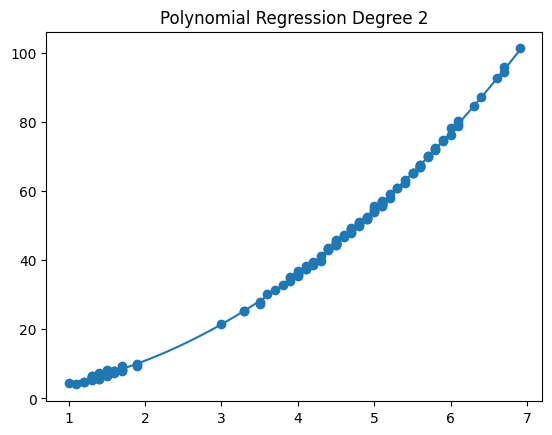

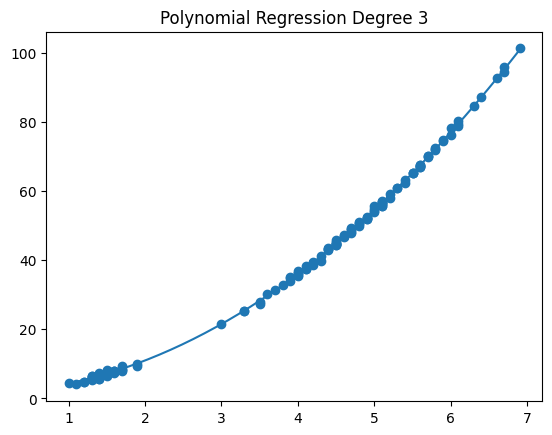

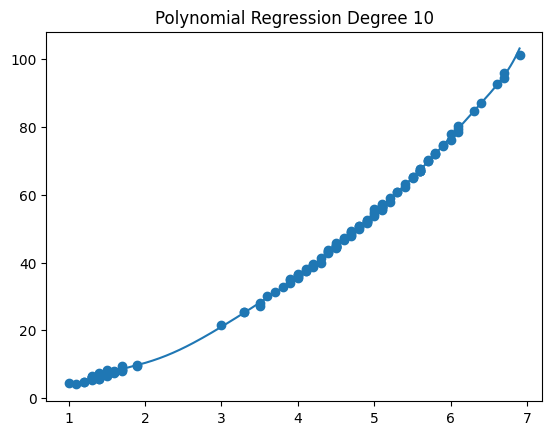

In [ ]:
for degree in degrees:

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Plot Polynomial Curve
    X_plot_poly = poly.transform(X_plot)
    y_plot_poly = model.predict(X_plot_poly)

    plt.figure()
    plt.scatter(X_reg, y_reg)
    plt.plot(X_plot, y_plot_poly)
    plt.title(f"Polynomial Regression Degree {degree}")
    plt.show()


In [ ]:
X_clf = iris.data[:, [2, 3]]  # Petal Length & Width
y_clf = iris.target

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)


In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_c, y_train_c)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_c = dt.predict(X_test_c)

print("Decision Tree Accuracy:",
      accuracy_score(y_test_c, y_pred_c))


Decision Tree Accuracy: 1.0


In [ ]:
importances = dt.feature_importances_

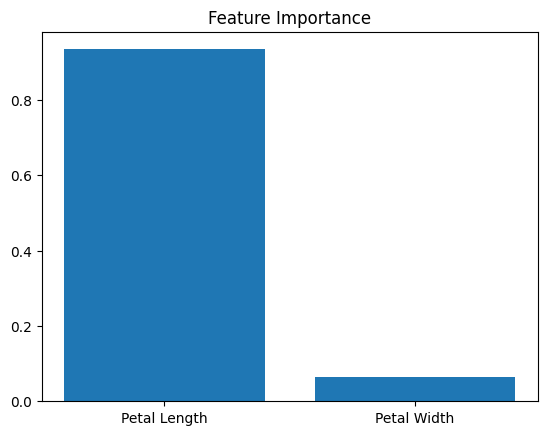

In [ ]:
plt.figure()
plt.bar(["Petal Length", "Petal Width"], importances)
plt.title("Feature Importance")
plt.show()

[Text(0.375, 0.875, 'Petal Length <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]\nclass = versicolor'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'Petal Length <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'Petal Width <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.75, 0.375, 'Petal Width <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 8\nvalue = [0, 4, 4]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.056\nsamples = 35\nvalue = [0, 1, 34]\nclass = virginica')]

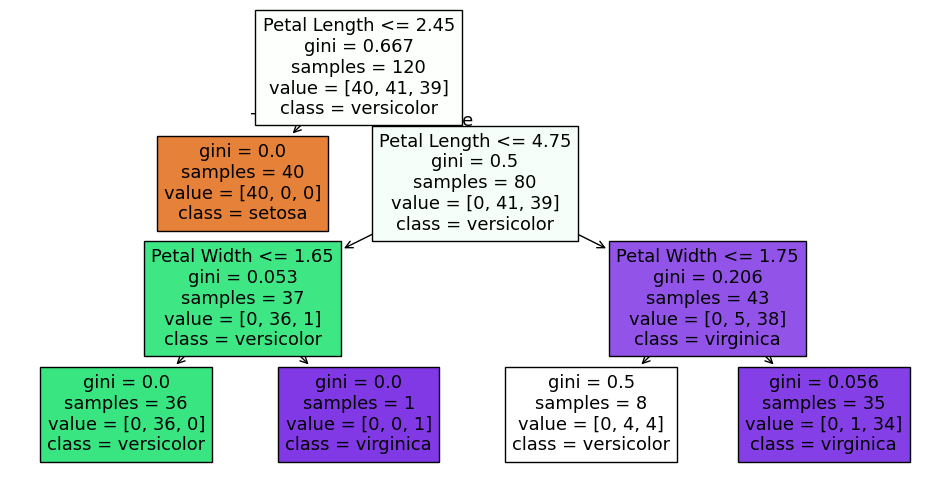

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(
    dt,
    feature_names=["Petal Length", "Petal Width"],
    class_names=iris.target_names,
    filled=True
)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

In [32]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train_c)

KNeighborsClassifier(n_neighbors=3)

In [33]:
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:",
      accuracy_score(y_test_c, y_pred_knn))

KNN Accuracy: 1.0
